In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from inputs_for_plots import *

In [19]:
def plot_error_distribution(df, ax=None, i =0, cl = None):

    err, _ = calc_error(df)
    err = err.apply(lambda x: np.abs(x))
    err.columns = cl

    long = err.melt(var_name="variable", value_name="value")

    # Get color palette
    palette = sns.color_palette(n_colors=err.shape[1])
    
    # Create the violin plot
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5))  # Erstelle nur eine neue Figur, wenn ax nicht übergeben wurde
    
    sns.boxplot(data=long, hue="variable", y="value",  palette=palette, ax=ax)

    # Draw the reference line
    ax.axhline(y=0, c="red", linestyle="--")
    ax.set_ylabel("Absolut deviation from true treatment effect",fontsize=20 )


    # Compute mean and standard deviation
    rmse = err.apply(lambda x: np.sqrt(np.mean(x**2)))
    mae = err.apply(lambda x: np.mean(x))
    std = err.apply(lambda x: np.std(x))

    handles = [
        mpatches.Patch(
            color=palette[i],
            label=f"RMSE = {rmse[col]:2.2f}, MAE = {mae[col]:2.2f}, Std = {std[col]:2.2f}  : {col}"
        )
        for i, col in enumerate(err.columns)
    ]

    ax.legend(handles=handles, loc="upper right", fontsize=22)
    return ax



# Plot increase in confounding

In [17]:
data1 = pd.read_csv(f"../treatment_effect_estimation/treatment_effect_estimations/true_sources_confounder_source_cn_{6}.csv", header=0, index_col=0)
data1

,seed,true_treatment_effect,estimated_treatment_using_confounder_source,ols_biased,column_extraction,level_of_confounding
1,0,-2.287634,-2.307301,-8.695015,1.011257,37.260063
2,1,1.355988,1.393716,6.432627,2.293385,6.686835
3,2,-1.383667,-1.402153,2.130759,-2.561314,17.165590
4,3,-2.399374,-2.328690,0.948301,-2.772299,3.521102
5,4,1.606548,1.605889,1.813219,1.759481,0.229584
...,...,...,...,...,...,...
91,95,0.651924,0.687960,-1.029955,1.587680,1.929886
92,96,2.471875,2.495742,8.318369,3.795309,19.730936
93,97,2.091629,2.094905,3.519187,2.896921,11.712632
94,98,-2.106264,-2.097058,0.343847,1.389027,4.095547


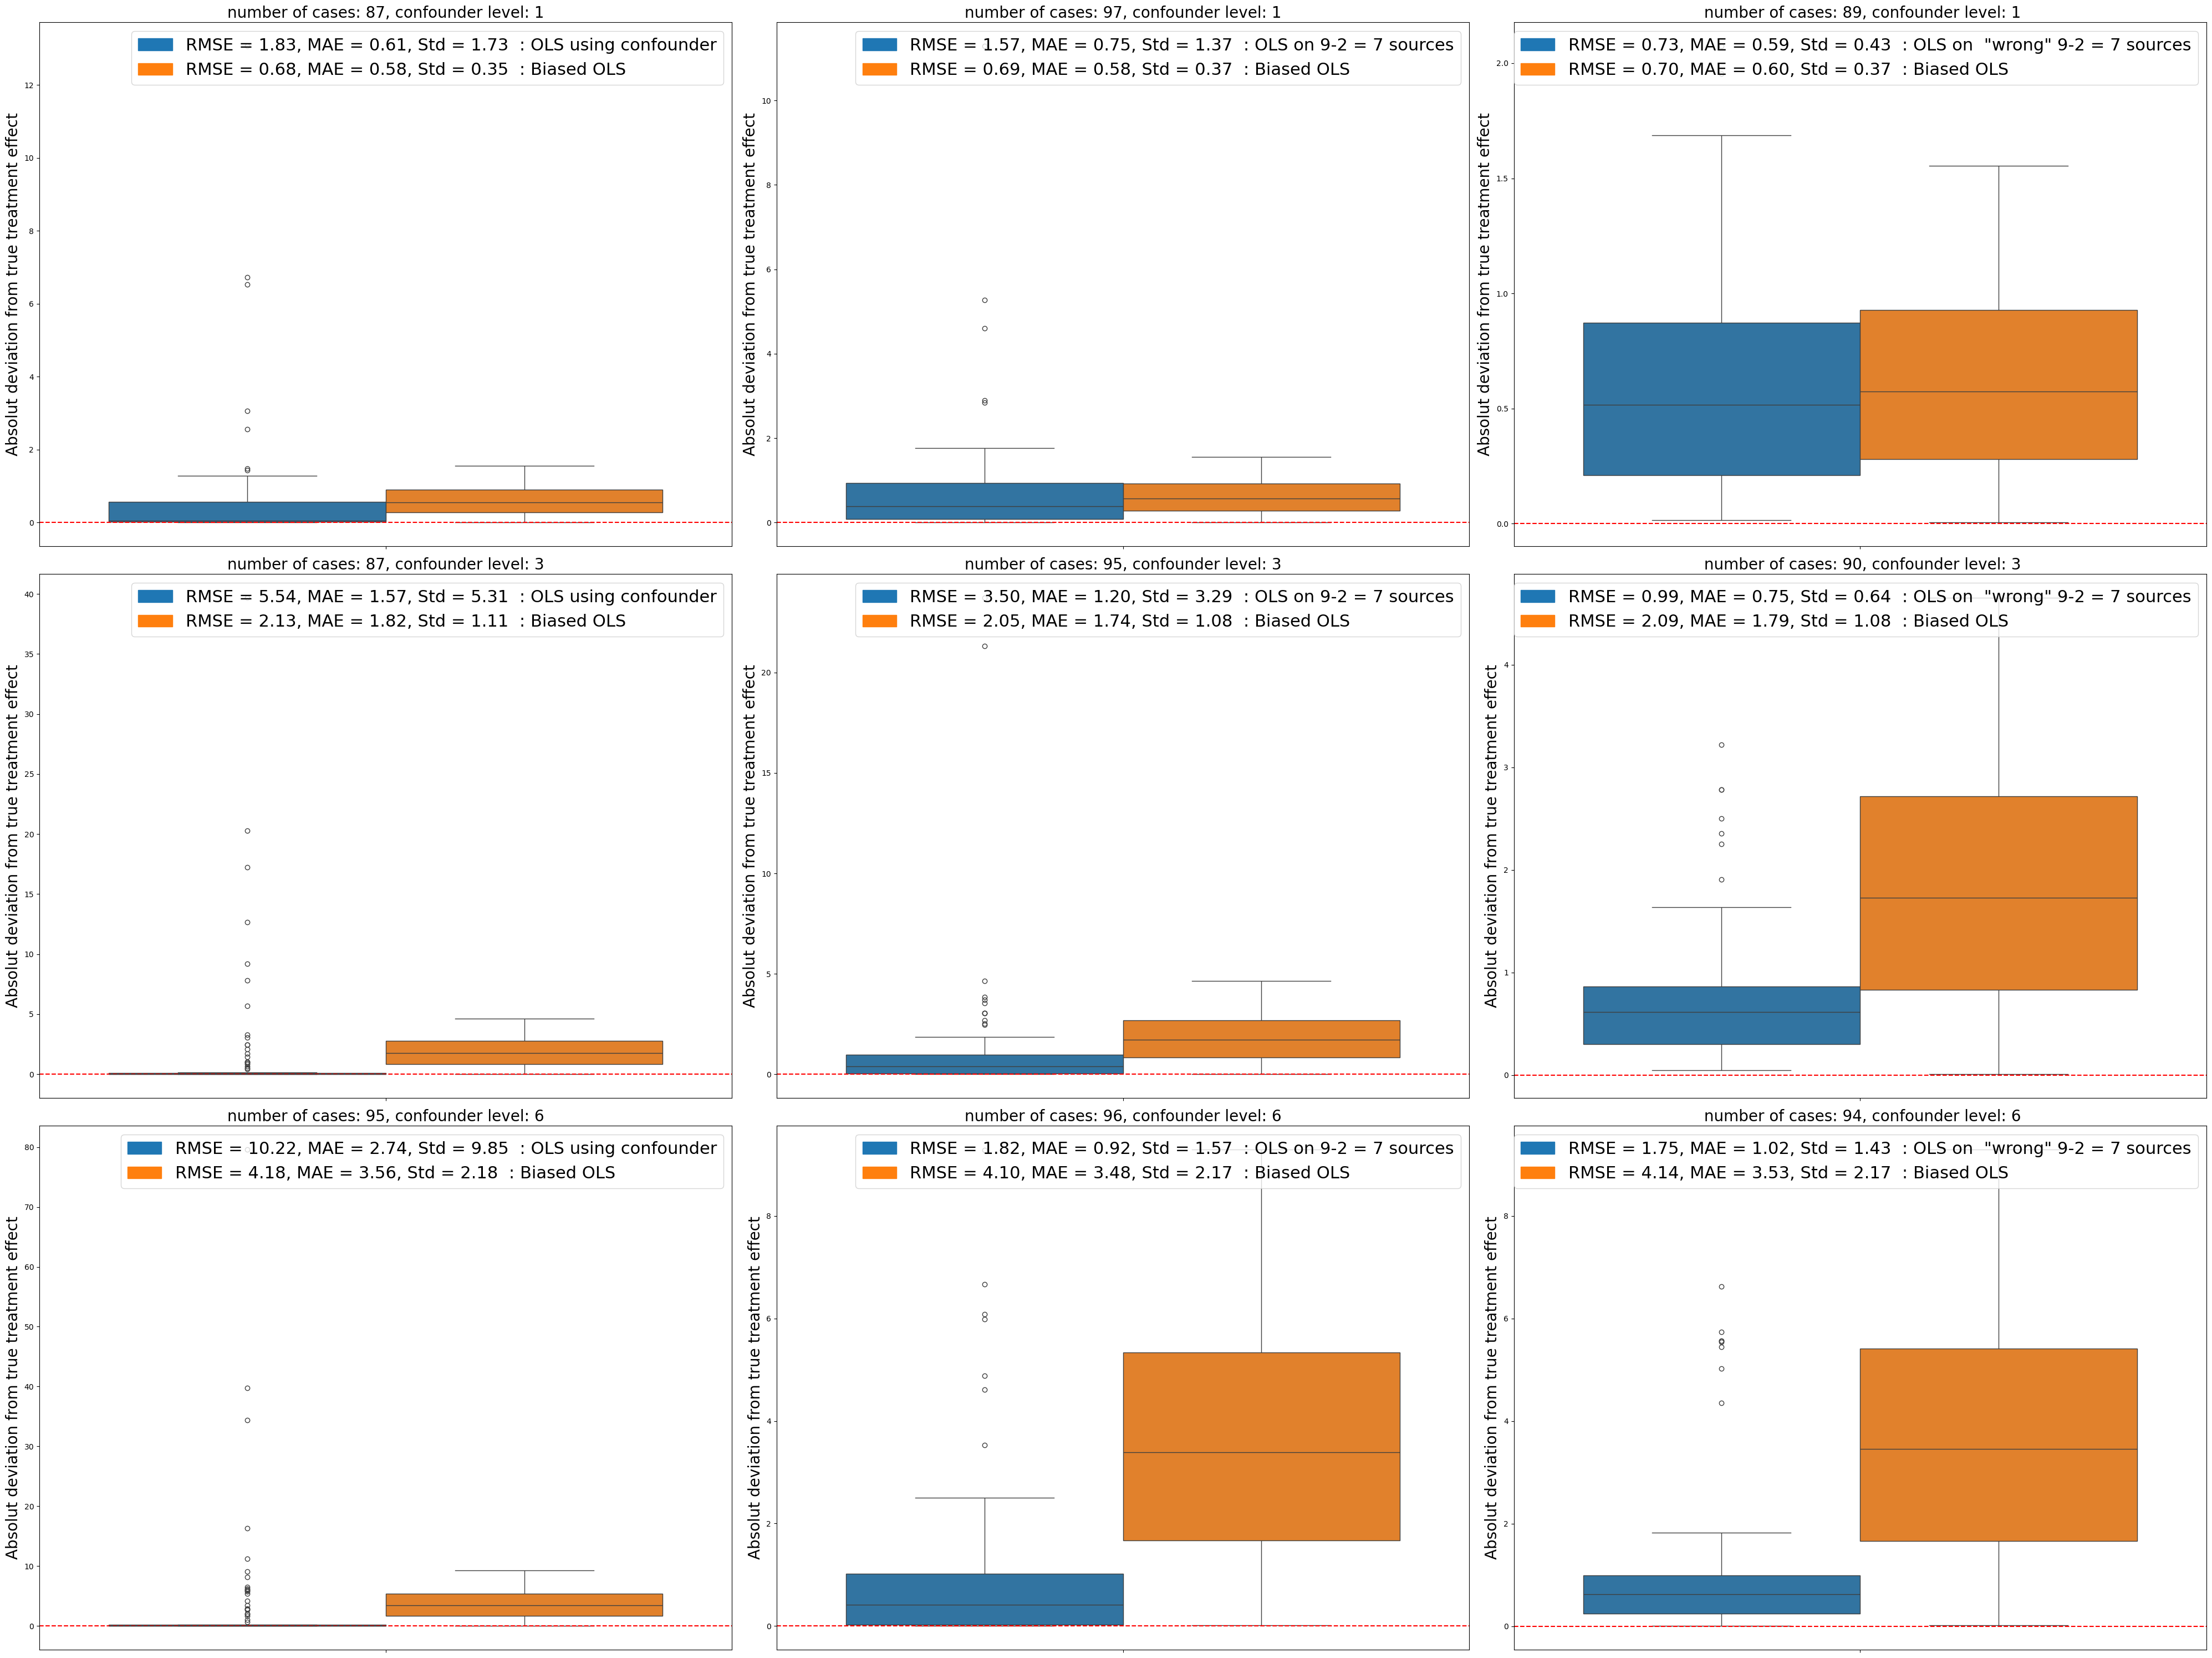

In [20]:



# Define subplot layout
fig, ax = plt.subplots(3, 3, figsize=(40, 30))
confounder_levels = [1, 3, 6]

for i, level in enumerate(confounder_levels):
    data1 = pd.read_csv(f"../treatment_effect_estimation/treatment_effect_estimations/true_sources_confounder_source_cn_{level}.csv", header=0, index_col=0)
    cl = ["OLS using confounder", "Biased OLS" ]
    plot_error_distribution(data1.drop("column_extraction", axis=1), ax[i, 0], i ,cl)
    ax[i, 0].set_title(f"number of cases: {data1.shape[0]}, confounder level: {level}", fontsize=20)

    data2 = pd.read_csv(f"../treatment_effect_estimation/treatment_effect_estimations/true_sources_7_sources_cn_{level}.csv", header=0, index_col=0)
    cl = ["OLS on 9-2 = 7 sources", "Biased OLS" ]
    plot_error_distribution(data2.drop("column_extraction", axis=1), ax[i, 1], i,cl)
    ax[i, 1].set_title(f"number of cases: {data2.shape[0]}, confounder level: {level}", fontsize=20)

    data3 = pd.read_csv(f"../treatment_effect_estimation/treatment_effect_estimations/true_sources_7_sources_nonsense_cn_{level}.csv", header=0, index_col=0)
    cl = ["OLS on  \"wrong\" 9-2 = 7 sources", "Biased OLS" ]
    plot_error_distribution(data3.drop("column_extraction", axis=1), ax[i, 2], i, cl)
    ax[i, 2].set_title(f" number of cases: {data3.shape[0]}, confounder level: {level}",fontsize=20)
plt.subplots_adjust(wspace=-0.2, hspace=0.3)
plt.tight_layout()
plt.show()
